In [26]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/carrie1/ecommerce-data/data.csv


In [27]:
#DATA CLEANING

In [28]:
import pandas as pd
import numpy as np

In [29]:
df = pd.read_csv('/kaggle/input/datasets/carrie1/ecommerce-data/data.csv', encoding= 'latin1')

In [30]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [32]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [33]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [34]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
print(df.shape)
df.describe()

(530104, 8)


,Quantity,UnitPrice,CustomerID
count,530104.000000,530104.000000,397884.000000
mean,10.542037,3.907625,15294.423453
std,155.524124,35.915681,1713.141560
min,1.000000,0.001000,12346.000000
25%,1.000000,1.250000,13969.000000
50%,3.000000,2.080000,15159.000000
75%,10.000000,4.130000,16795.000000
max,80995.000000,13541.330000,18287.000000


In [35]:
df.dropna(subset=['CustomerID'],inplace=True)
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.3+ MB


In [36]:
df = df[(df['Quantity']>0) & (df['UnitPrice']>0)]

df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,397884.000000,397884,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,179.331775,NaN,22.097877,1713.141560


In [37]:
print(df.duplicated().sum())

5192


In [38]:
df.drop_duplicates(inplace=True)

I removed 135,080 rows missing Customer IDs because i could not perform user specific analysis without them. Then I also removed negative quantities and prices, which likely represented cancelled orders or system errors, to ensure the revenue totals are accurate. last but not least i also identified and removed duplicates.

In [39]:
#Analysis

In [40]:
# REVENUE TRENDS OVER TIME
df['Revenue'] = df['Quantity'] * df['UnitPrice']

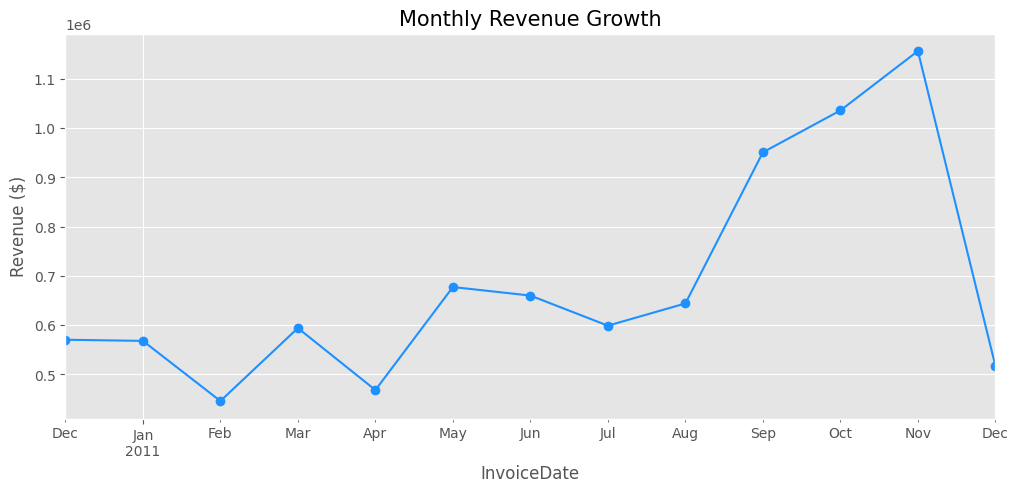

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('ggplot')

# 1. Revenue Trend Over Time
plt.figure(figsize=(12, 5))
df.set_index('InvoiceDate')['Revenue'].resample('ME').sum().plot(marker='o', color='dodgerblue')
plt.title('Monthly Revenue Growth', fontsize=15)
plt.ylabel('Revenue ($)')
plt.show()




Revenue remians stable for majority of the year however grows exponentially beginning in September, peaking in November.****

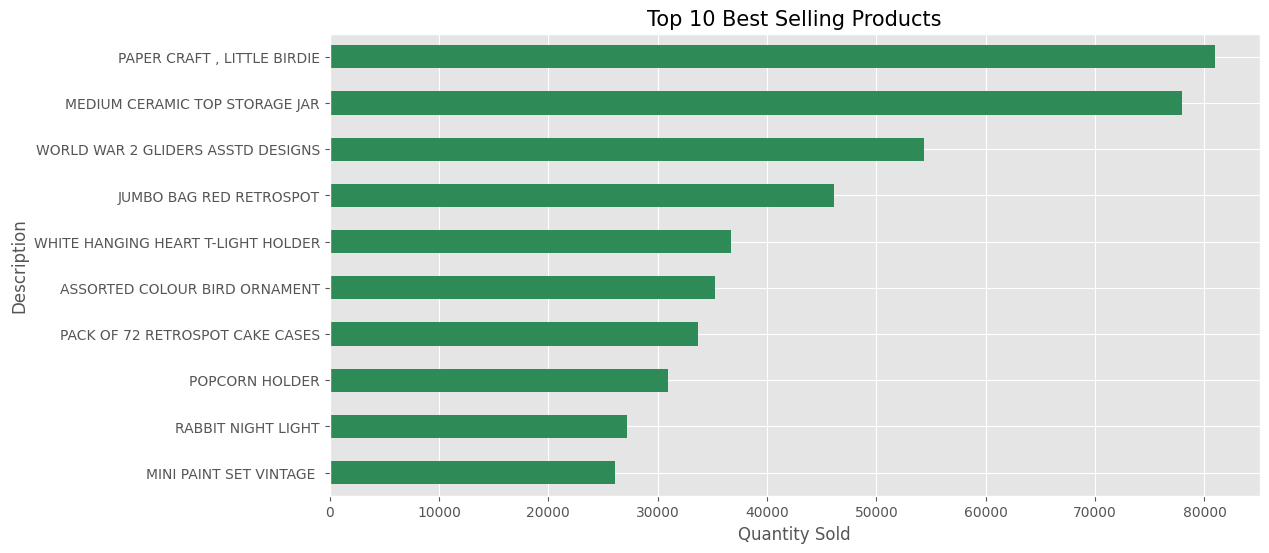

In [42]:
# 2. Top 10 Products by Quantity
plt.figure(figsize=(12, 6))
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10).plot(kind='barh', color='seagreen')
plt.title('Top 10 Best Selling Products', fontsize=15)
plt.xlabel('Quantity Sold')
plt.gca().invert_yaxis()
plt.show()

A small group of items, such as the 'Jumbo Bag Red Retrospot' accounts for a unbalanced amount of total units sold.

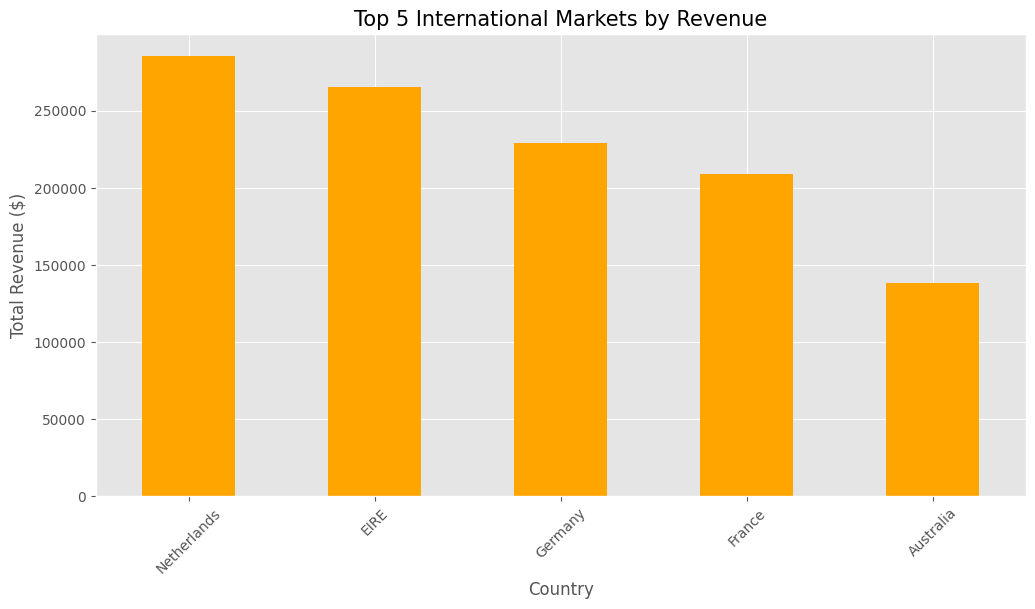

In [43]:
# 3. Top 5 International Markets (Excluding UK)
plt.figure(figsize=(12, 6))
df[df['Country'] != 'United Kingdom'].groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5).plot(kind='bar', color='orange')
plt.title('Top 5 International Markets by Revenue', fontsize=15)
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.show()

Even though the business is UK centric, the European market(France, Germany and Netherlands) shows the highest average transaction value 

Business Advice 

The data proves a massive spike in November. The client should increase warehouse staffing and stock levels by at least 40% starting in early October to avoid bottlenecks and 'Out of Stock' messages during the peak holiday rush. 
Since the the Nertherlands and Germany are high revenue international hubs,we should explore lowering shipping costs or setting up a small distribution center in mainland Europe to increase the competitiveness of our pricing in those regions.
We should create 'Bundle Deals' or subscriptions models for our top 10 best selling items. Since customers already buy these in high volume, a loyalty program would secure long term recurring revenue and protect against competitors.